In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import quad, simps, cumtrapz
from scipy.optimize import curve_fit
from scipy.special import erf
from scipy.interpolate import interp1d
from scipy.stats import gaussian_kde

import sympy as sp
import matplotlib.patches as mpatches

from astropy.cosmology import Planck18 as cosmo, z_at_value, FlatLambdaCDM
from astropy import units as u

In [2]:
# ============================================================================
# TELESCOPE SELECTION
# ============================================================================
TELESCOPE = "D0"
# Other options: "Fast", "Meerkat_incoherent", "Meerkat_coherent", "askap_ics", "askap_flyeye"

TELESCOPE_PARAMS = {


    "d0": {
        "D":12,
        "eta": 0.6,
        "Trec": 22,
        "Tsky": 3,
        "BW": 300e6,
        "nu_cen": 1.4e9,
        "n_comp": 16,
        "n_chan": 1024,
        "tsamp": 1.e-3,

    },

    "5d0": {
        "D":5*12,
        "eta": 0.6,
        "Trec": 22,
        "Tsky": 3,
        "BW": 300e6,
        "nu_cen": 1.4e9,
        "n_comp": 16,
        "n_chan": 1024,
        "tsamp": 1.e-3,

    },

    "25d0": {
        "D":25*12,
        "eta": 0.6,
        "Trec": 22,
        "Tsky": 3,
        "BW": 300e6,
        "nu_cen": 1.4e9,
        "n_comp": 16,
        "n_chan": 1024,
        "tsamp": 1.e-3,

    }
}


In [3]:
alpha_intrinsic = -1.5  # Fixed intrinsic spectral index

In [4]:

# EFFECT CONTROL FLAGS
# ============================================================================
USE_COSMOLOGY = True      # Tozggle Euclidean vs cosmological universe (affects distances, volumes)
USE_SFR = True           
USE_SMEARING = True      
USE_SPECTRAL_INDEX = True 


# USE_COSMOLOGY = False
# USE_SFR = False           
# USE_SMEARING = False    
# USE_SPECTRAL_INDEX = False

USE_BEAM = True
# USE_BEAM = False

# # Luminosity function parameters
LUMINOSITY_FUNCTION = "schechter"  
# LUMINOSITY_FUNCTION = "std" 

In [5]:


# Load selected telescope
if TELESCOPE.lower() not in TELESCOPE_PARAMS:
    raise ValueError(f"Telescope must be one of: {list(TELESCOPE_PARAMS.keys())}")

params = TELESCOPE_PARAMS[TELESCOPE.lower()]

# Physical constants
k = 1.38e-23
c = 3.0e8

# Extract telescope parameters
D = params["D"]
eta = params["eta"]
# n_dishes = params.get("n_dishes", 1)
# mode = params.get("mode", "single")

# n_beams = params.get("n_beams", 1) if mode != "coherent" and mode != "incoherent" else 1
# array_gain_factor = n_dishes if mode == "coherent" else np.sqrt(n_dishes) if mode == "incoherent" else 1
G0 = np.pi * D*D/4 * eta/2.0/k*1e-26
Np = 2
Trec = params["Trec"]
Tsky = params["Tsky"]
BW = params["BW"]
n_comp = params["n_comp"]
BW_comp = BW / n_comp
n_chan = params["n_chan"]
BW_chan = BW / n_chan
nu_cen = params["nu_cen"]
nu_min = nu_cen - BW / 2
nu_max = nu_cen + BW / 2
nu_array = np.linspace(nu_min, nu_max, n_comp+1)

print(f"{'='*100}")
print(f"TELESCOPE: {TELESCOPE}")
print(f"  Diameter: {D} m")
print(f"  Receiver temp: {Trec} K")
print(f"  Bandwidth: {BW/1e6:.0f} MHz at {nu_cen/1e9:.3f} GHz")
# print(f"  N_dishes: {n_dishes}, Mode: {mode}")
# print(f"  FoV: {params['fov']} deg²")
print(f"{'='*100}\n")


TELESCOPE: D0
  Diameter: 12 m
  Receiver temp: 22 K
  Bandwidth: 300 MHz at 1.400 GHz



In [6]:
# ============================================================================
# REDSHIFT PARAMETERS
# ============================================================================
dz = 0.01
z_min = 0.01
z_max = 5.0
z_array_opt = np.arange(z_min, z_max, dz)

# Options: "schechter" or "std"

L_STAR = 1e15  # Characteristic luminosity (Jy·kpc²)
ALPHA_SCH = -1.5  # Faint-end slope
L_MIN_SCH = 1e10
L_MAX_SCH = 1e16

L_std = 2.4e14  # Jy·kpc²

# Simulation parameters
theta_max = 2*1.22*c/D/nu_min # please note here
fscale = 0.2 * 1e-7  # FRB rate scaling factor

SNR_threshold = 10
t_obs = 0.001
TARGET_DETECTIONS = 10  # Target 10 detections per z-bin

# Cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

fwhm_rad = 1.22 * (c / nu_min) / D
fwhm_deg = fwhm_rad * (180 / np.pi)
r_deg = 2.0 * fwhm_deg
area = np.pi * (r_deg)**2
# area = params['fov']  # Area of sky in square degrees

# Calculate frequency-dependent scattering term
freq_powers_scatter = np.array([(nu_min * BW_comp * (i+1))**(-4) for i in range(n_comp)])

np.random.seed(42)


In [7]:
def gaussian_beam_gain(nu, G0, theta, D, c):
    """
    Gaussian beam gain with frequency dependence
    G(ν) = G₀ × exp[−θ²ν²D²×2.355²/(2×1.22²×c²)]
    """
    # Exponent coefficient
    coeff = (theta**2 * D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    return G0 * np.exp(-coeff * nu**2)

# Pre-calculate constants for speed
_COEFF_CONST = (2.355**2) / (2 * 1.22**2 * (3.0e8**2))

def gaussian_beam_gain_fast(nu_array, G0, theta, D):
    """Optimized version for the inner loop"""
    coeff = theta**2 * D**2 * _COEFF_CONST
    return G0 * np.exp(-coeff * nu_array**2)

def tophat_beam_gain(nu, G0, theta, theta_max):
    """Tophat beam: constant G0 within theta_max/2, zero outside."""
    gain = G0 if theta <= (theta_max / 2) else 0.0
    return np.full_like(nu, gain, dtype=float) if np.ndim(nu) else float(gain)

def SNR(S,t,G,BW,Np,Trec,Tsky):
    return(S*G*np.sqrt(BW*t*Np)/(Trec+Tsky))

In [8]:
def schechter_function(L, L_star, alpha, phi_star=1.0):
    """
    Schechter luminosity function.
    
    φ(L) = φ* (L/L*)^α * exp(-L/L*)
    
    Parameters:
    -----------
    L : float or array
        Luminosity
    L_star : float
        Characteristic luminosity (knee of the function)
    alpha : float
        Faint-end slope (typically negative)
    phi_star : float
        Normalization constant (default: 1.0)
    
    Returns:
    --------
    phi : float or array
        Number density at luminosity L
    """
    x = L / L_star
    return phi_star * x**alpha * np.exp(-x)

In [9]:
def create_truncated_schechter_sampler(L_min, L_max, L_star, alpha):
    """Create sampler for Schechter function truncated between L_min and L_max"""
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), 2000)
    phi_grid = schechter_function(L_grid, L_star, alpha)
    
    # REMOVE THIS LINE:
    # from scipy.integrate import cumtrapz
    
    cdf = cumtrapz(phi_grid, L_grid, initial=0)
    cdf = cdf / cdf[-1]
    
    inv_cdf = interp1d(cdf, L_grid, kind='linear', 
                       bounds_error=False, fill_value=(L_min, L_max))
    return inv_cdf

In [10]:

# ============================================================================
# CREATE TRUNCATED SCHECHTER SAMPLER FOR EACH Z
# ============================================================================
print("Creating truncated Schechter samplers...")

def create_truncated_schechter_sampler(L_min, L_max, L_star, alpha):
    """Create sampler for Schechter function truncated between L_min and L_max"""
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), 2000)
    phi_grid = schechter_function(L_grid, L_star, alpha)
    
    from scipy.integrate import cumtrapz
    cdf = cumtrapz(phi_grid, L_grid, initial=0)
    cdf = cdf / cdf[-1]
    
    inv_cdf = interp1d(cdf, L_grid, kind='linear', 
                       bounds_error=False, fill_value=(L_min, L_max))
    return inv_cdf

sampler_cache = {}
print(f"  Done!\n")

def std_sampler(L_candle):
    """Return a fixed luminosity sampler for standard candle model"""
    def sampler(u):
        return L_candle
    return sampler

Creating truncated Schechter samplers...
  Done!



In [11]:
# ============================================================================
# MULTI-TELESCOPE COMPARISON WITH SPECTRAL INDEX INFERENCE
# ============================================================================

print("\n" + "="*100)
print("RUNNING 3-TELESCOPE COMPARISON WITH SPECTRAL INDEX INFERENCE")
print("="*100 + "\n")

# Store results for each telescope
all_results = {}
colors_tel = {
    "d0": "#1f77b4",      # blue
    "5d0": "#ff7f0e",     # orange
    "25d0": "#2ca02c"     # green
}
labels_tel = {
    "d0": "D0 (12m)",
    "5d0": "5D0 (60m)",
    "25d0": "25D0 (300m)"
}

# Save original telescope parameters
D_orig = D
G0_orig = G0
theta_max_orig = theta_max
params_orig = params.copy()

# Define once for the Euclidean branch
H0_km_s_Mpc = cosmo.H0.value if hasattr(cosmo, "H0") else 70.0
DH_Mpc = 299792.458 / H0_km_s_Mpc

# Store inferred alpha SEPARATELY FOR EACH TELESCOPE
alpha_inferred_by_telescope = {
    "d0": [],
    "5d0": [],
    "25d0": []
}
alpha_error_by_telescope = {
    "d0": [],
    "5d0": [],
    "25d0": []
}
snr_by_telescope = {
    "d0": [],
    "5d0": [],
    "25d0": []
}

# Loop through all telescopes
for tel_key in ["d0", "5d0", "25d0"]:
    print(f"\n{'='*60}")
    print(f"TELESCOPE: {labels_tel[tel_key]}")
    print(f"{'='*60}")

    # Update telescope parameters
    params = TELESCOPE_PARAMS[tel_key]
    D = params["D"]
    G0 = np.pi * D * D / 4 * eta / 2.0 / k * 1e-26
    theta_max = 2 * 1.22 * c / D / nu_min

    # Recalculate area for this telescope
    fwhm_rad = 1.22 * (c / nu_min) / D
    fwhm_deg = fwhm_rad * (180 / np.pi)
    r_deg = 2.0 * fwhm_deg
    area_tel = np.pi * (r_deg)**2

    print(f"  Diameter: {D} m, G0: {G0:.4e}, theta_max: {theta_max:.6f}")
    print(f"  Sky area: {area_tel:.4f} deg²")

    # Independent seed for repeatability
    np.random.seed(42)

    # Re-compute L_min_by_z for this telescope
    L_min_by_z_new = {}
    nu0 = nu_cen

    for z in z_array_opt:
        if USE_COSMOLOGY:
            dl = cosmo.luminosity_distance(z).value * 1000.0   # kpc
        else:
            dl = (DH_Mpc * z) * 1000.0                          # kpc

        G_max = gaussian_beam_gain(nu0, G0, 0, D, 3.0e8)
        S_min = SNR_threshold * (Trec + Tsky) / (G_max * np.sqrt(BW * t_obs * Np))
        
        if USE_SPECTRAL_INDEX:
            z_factor = (1 + z)**(-1 - alpha_intrinsic)
        else:
            z_factor = 1.0

        L_min = S_min * (dl**2) * z_factor
        L_min_by_z_new[z] = np.clip(L_min, L_MIN_SCH, L_MAX_SCH)

    sampler_cache.clear()

    # Run simulation for this telescope
    results_tel = []
    _INNER_COEFF_CONST_new = (D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    S_SNR_CONST = np.sqrt(BW_comp * t_obs * Np) / (Trec + Tsky)

    if USE_SPECTRAL_INDEX:
        nu_scaling = (nu_array / nu0)**alpha_intrinsic
    else:
        nu_scaling = np.ones_like(nu_array)

    for z_idx, z in enumerate(z_array_opt):
        zmin = z - 0.5 * dz
        zmax = z + 0.5 * dz
        L_min_z = L_min_by_z_new[z]

        if LUMINOSITY_FUNCTION.lower() == "std":
            if L_min_z > L_std:
                break
        else:
            if L_min_z > 8.952e15:
                break

        if LUMINOSITY_FUNCTION.lower() == "std":
            truncated_sampler = std_sampler(L_std)
        else:
            if L_min_z not in sampler_cache:
                sampler_cache[L_min_z] = create_truncated_schechter_sampler(
                    L_min_z, L_MAX_SCH, L_STAR, ALPHA_SCH
                )
            truncated_sampler = sampler_cache[L_min_z]

        DM = 1000 * z
        wi_z = 0.001 * (1 + z)
        BW_chan_MHz = BW_chan / 1e6
        nu_cen_GHz = nu_cen / 1e9

        if USE_SMEARING:
            w_DM = 8.3e-6 * DM * BW_chan_MHz / (nu_cen_GHz**3)
            w_scatter_comp = (
                1.9e-7 * (DM**1.5) * (1 + (DM**3) * 3.55e-5) * 3 * freq_powers_scatter * 1e-3
            )
            w_scatter = np.sqrt(np.sum(w_scatter_comp**2) / len(w_scatter_comp))
            w_sampling = params["tsamp"] * 1e-3
        else:
            w_DM = 0.0
            w_scatter = 0.0
            w_sampling = 0.0

        w_obs_factor = np.sqrt(wi_z**2 + w_DM**2 + w_scatter**2 + w_sampling**2)

        if USE_COSMOLOGY:
            dl = cosmo.luminosity_distance(z).value * 1000.0
        else:
            dl = (DH_Mpc * z) * 1000.0

        if USE_SPECTRAL_INDEX:
            z_factor = (1 + z)**(-1 - alpha_intrinsic)
        else:
            z_factor = 1.0

        theta_hp = np.sqrt(np.log(2) / (_INNER_COEFF_CONST_new * nu0**2))

        # ===== INITIALIZE TRACKING ARRAYS FOR THIS Z-SHELL =====
        shell_alpha_inferred = []
        shell_alpha_error = []
        shell_snr_coherent = []

        n_generated = 0
        n_detected = 0
        detected_luminosities = []
        detected_snrs = []
        max_iterations = 1000000

        while n_detected < TARGET_DETECTIONS and n_generated < max_iterations:
            n_generated += 1
            theta_frb = theta_max * np.sqrt(np.random.random())

            if theta_frb > 4.0 * theta_hp:
                continue

            lum = float(truncated_sampler(np.random.uniform(0, 1)))
            S0_frb = (lum / (dl**2 * z_factor)) * (wi_z / w_obs_factor)
            S_nu = S0_frb * nu_scaling

            if USE_BEAM:
                G_nu = G0 * np.exp(-(_INNER_COEFF_CONST_new * theta_frb**2) * nu_array**2)
            else:
                G_nu = G0 * np.exp(-(_INNER_COEFF_CONST_new * 0.0**2) * nu_array**2)

            snr_spectrum = S_nu * G_nu * S_SNR_CONST
            snr_coherent = np.sum(snr_spectrum) / np.sqrt(n_comp)

            if snr_coherent > SNR_threshold:
                n_detected += 1
                detected_luminosities.append(lum)
                detected_snrs.append(snr_coherent)
                
                # ===== SPECTRAL INDEX INFERENCE =====
                shell_snr_coherent.append(snr_coherent)
                
                try:
                    # Use ALL channels for fitting
                    nu_fit = nu_array
                    snr_fit = snr_spectrum  # Use all channels
                    
                    # Prepare for Log-Log Fit
                    log_nu = np.log10(nu_fit / nu0)
                    log_snr = np.log10(snr_fit)
                    
                    # Calculate Uncertainties in Log Space
                    # SNR uncertainty = 1.0 (by definition)
                    # Error propagation: sigma_log_y = sigma_y / (y * ln(10))
                    sigma_log_snr = 1.0 / (snr_fit * np.log(10))
                    
                    # Weights = 1 / variance
                    weights = 1.0 / sigma_log_snr**2
                    
                    # Weighted Linear Regression with covariance
                    coeffs = np.polyfit(log_nu, log_snr, 1, w=weights, cov=True)
                    slope = coeffs[0][0]
                    cov_matrix = coeffs[1]
                    sigma_slope = np.sqrt(cov_matrix[0, 0])
                    
                    shell_alpha_inferred.append(slope)
                    shell_alpha_error.append(sigma_slope)
                    
                except Exception as e:
                    shell_alpha_inferred.append(np.nan)
                    shell_alpha_error.append(np.nan)

        if n_detected == TARGET_DETECTIONS:
            detection_rate = n_detected / n_generated

            if LUMINOSITY_FUNCTION.lower() == "std":
                N_ratio = 1.0 if L_std >= L_min_z else 0.0
            else:
                L_grid_full = np.logspace(np.log10(L_MIN_SCH), np.log10(L_MAX_SCH), 5000)
                phi_grid_full = schechter_function(L_grid_full, L_STAR, ALPHA_SCH)
                cdf_full = cumtrapz(phi_grid_full, L_grid_full, initial=0)
                cdf_full /= cdf_full[-1]
                cdf_interp = interp1d(L_grid_full, cdf_full, kind="linear")
                N_ratio = 1.0 - cdf_interp(L_min_z)

            if USE_COSMOLOGY:
                dt = (cosmo.age(zmin).value - cosmo.age(zmax).value) * 1e9
                dvol = (
                    cosmo.comoving_volume(zmax).value - cosmo.comoving_volume(zmin).value
                ) * (area_tel / (4.0 * np.pi * ((180.0 / np.pi)**2)))
            else:
                r_Mpc = DH_Mpc * z
                dr_Mpc = DH_Mpc * dz
                area_sr = area_tel * (np.pi / 180.0)**2
                dvol = (r_Mpc**2) * dr_Mpc * area_sr
                dr_m = dr_Mpc * 3.0857e22
                dt = dr_m / c / (3600.0 * 24.0 * 365.0)

            if USE_SFR:
                psi = 0.015 * ((1 + z)**2.7) / (1 + ((1 + z) / 2.9)**5.6)
            else:
                psi = 0.015

            nfrb_sfr = psi * dvol * dt * fscale
            n_total_population = detection_rate * N_ratio * nfrb_sfr

            results_tel.append({
                "z": z,
                "DM": DM,
                "n_total_population": n_total_population,
                "alpha_inferred": np.array(shell_alpha_inferred),
                "alpha_error": np.array(shell_alpha_error),
                "snr_coherent": np.array(shell_snr_coherent)
            })
            
            # Accumulate inferred alpha for this telescope
            alpha_inferred_by_telescope[tel_key].extend(shell_alpha_inferred)
            alpha_error_by_telescope[tel_key].extend(shell_alpha_error)
            snr_by_telescope[tel_key].extend(shell_snr_coherent)

            if z_idx % 50 == 0:
                print(f"  z={z:.2f}: Pop {n_total_population:.1f}, Detected α (mean): {np.nanmean(shell_alpha_inferred):.3f}±{np.nanstd(shell_alpha_inferred):.3f}")

    print(f"  ✓ Results: {len(results_tel)} redshift bins")
    all_results[tel_key] = results_tel

# Restore original parameters
params = params_orig
theta_max = theta_max_orig
G0 = G0_orig
D = D_orig

# Convert to numpy arrays for each telescope
for tel_key in ["d0", "5d0", "25d0"]:
    alpha_inferred_by_telescope[tel_key] = np.array(alpha_inferred_by_telescope[tel_key])
    alpha_error_by_telescope[tel_key] = np.array(alpha_error_by_telescope[tel_key])
    snr_by_telescope[tel_key] = np.array(snr_by_telescope[tel_key])

print(f"\n{'='*100}")
print("SPECTRAL INDEX ANALYSIS BY TELESCOPE")
print(f"{'='*100}")

for tel_key in ["d0", "5d0", "25d0"]:
    valid_mask = ~np.isnan(alpha_inferred_by_telescope[tel_key])
    valid_alphas = alpha_inferred_by_telescope[tel_key][valid_mask]
    
    print(f"\n{labels_tel[tel_key]}:")
    print(f"  Total detected FRBs: {len(alpha_inferred_by_telescope[tel_key])}")
    print(f"  Valid inferred α: {np.sum(valid_mask)}")
    if np.sum(valid_mask) > 0:
        print(f"  Inferred α (mean ± std): {np.mean(valid_alphas):.3f} ± {np.std(valid_alphas):.3f}")
        print(f"  Inferred α range: [{np.min(valid_alphas):.3f}, {np.max(valid_alphas):.3f}]")
        print(f"  Mean α error: {np.nanmean(alpha_error_by_telescope[tel_key][valid_mask]):.3f}")

print(f"{'='*100}\n")


RUNNING 3-TELESCOPE COMPARISON WITH SPECTRAL INDEX INFERENCE


TELESCOPE: D0 (12m)
  Diameter: 12 m, G0: 2.4586e-02, theta_max: 0.048800
  Sky area: 24.5604 deg²
  z=0.01: Pop 2.6, Detected α (mean): -4.039±2.569


/tmp/ipykernel_4162098/4221973470.py:12: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  cdf = cumtrapz(phi_grid, L_grid, initial=0)
/tmp/ipykernel_4162098/1040373529.py:234: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  cdf_full = cumtrapz(phi_grid_full, L_grid_full, initial=0)


  z=0.51: Pop 21.1, Detected α (mean): -2.699±1.258
  z=1.01: Pop 1.3, Detected α (mean): -2.356±0.681
  z=1.51: Pop 0.0, Detected α (mean): -1.813±0.343
  z=2.01: Pop 0.0, Detected α (mean): -1.662±0.108
  ✓ Results: 238 redshift bins

TELESCOPE: 5D0 (60m)
  Diameter: 60 m, G0: 6.1466e-01, theta_max: 0.009760
  Sky area: 0.9824 deg²
  z=0.01: Pop 0.5, Detected α (mean): -5.415±2.483
  z=0.51: Pop 10.5, Detected α (mean): -3.858±1.876
  z=1.01: Pop 12.8, Detected α (mean): -3.634±1.208
  z=1.51: Pop 2.3, Detected α (mean): -3.131±0.931
  z=2.01: Pop 0.6, Detected α (mean): -2.617±0.914
  z=2.51: Pop 0.1, Detected α (mean): -2.445±0.557
  z=3.01: Pop 0.0, Detected α (mean): -1.889±0.343
  z=3.51: Pop 0.0, Detected α (mean): -2.058±0.529
  z=4.01: Pop 0.0, Detected α (mean): -1.792±0.210
  z=4.51: Pop 0.0, Detected α (mean): -1.760±0.211
  ✓ Results: 499 redshift bins

TELESCOPE: 25D0 (300m)
  Diameter: 300 m, G0: 1.5366e+01, theta_max: 0.001952
  Sky area: 0.0393 deg²
  z=0.01: Pop 0.0,

✓ Plot created with PDF histograms and configuration box



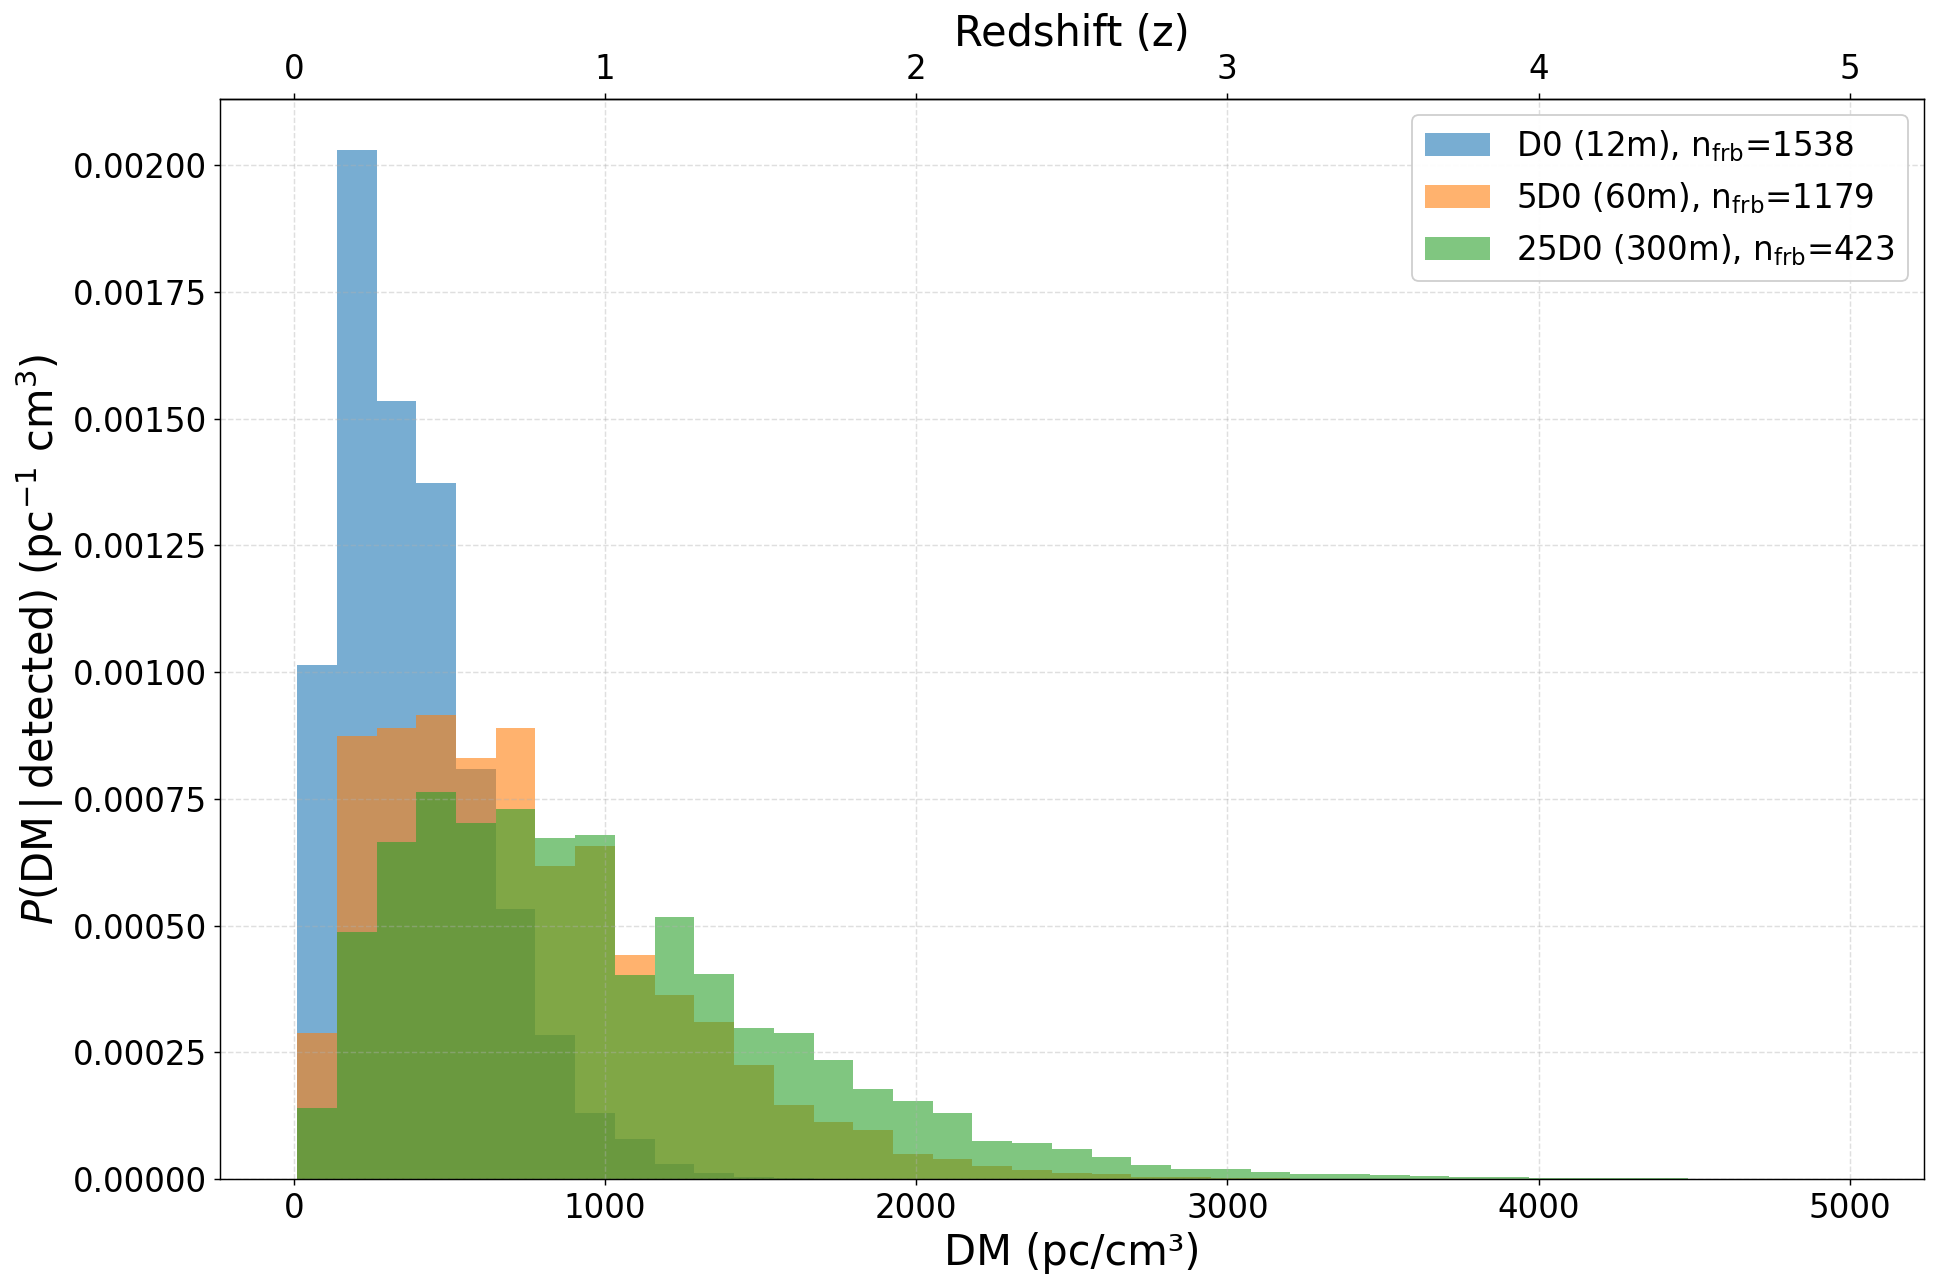

MULTI-TELESCOPE COMPARISON COMPLETE


In [12]:
fig, ax = plt.subplots(figsize=(15, 10), dpi=130)

# Find global DM range
dm_min = min([1000*r[0]['z'] for r in [all_results[k] for k in all_results if len(all_results[k]) > 0]])
dm_max = max([1000*r[-1]['z'] for r in [all_results[k] for k in all_results if len(all_results[k]) > 0]])
common_bins = np.linspace(dm_min, dm_max, 40)

# Plot histograms for each telescope
for tel_key in ['d0', '5d0', '25d0']:
    if tel_key in all_results and len(all_results[tel_key]) > 0:
        results = all_results[tel_key]
        DMs = np.array([r['DM'] for r in results])
        pops = np.array([r['n_total_population'] for r in results])
        
        # Create histogram as a Probability Density Function (PDF)
        # density=True ensures the integral over the histogram = 1.0 (P(DM|detected))
        ax.hist(DMs, bins=common_bins, weights=pops, density= True, alpha=0.6,
                label=f'{labels_tel[tel_key]}, n$_{{\\mathrm{{frb}}}}$={int(pops.sum())}', color=colors_tel[tel_key], linewidth=1.5)

# Create secondary x-axis for redshift (z)
ax2 = ax.secondary_xaxis('top', functions=(lambda x: x/1000, lambda x: x*1000))
ax2.set_xlabel('Redshift (z)', fontsize=23)
ax2.tick_params(axis='x', labelsize=18)

# Set labels and title
ax.set_xlabel('DM (pc/cm³)', fontsize=23)
ax.set_ylabel(r'$P(\mathrm{DM}\,|\,\mathrm{detected})$ (pc$^{-1}$ cm$^3$)', fontsize=23)
# title = f'Multi-Telescope FRB DM Probability Distribution (α = {alpha_intrinsic})' if USE_SPECTRAL_INDEX else 'Multi-Telescope FRB DM Probability Distribution'
# ax.set_title(title, fontsize=20, fontweight='bold')

# Increase tick label sizes
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

# Add grid for both x and y
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)

# Increase legend font size
ax.legend(fontsize=18, loc='upper right', framealpha=0.95)

# Create configuration text box
config_text = (
    f"CONFIGURATION:\n"
    f"USE_COSMOLOGY: {USE_COSMOLOGY}\n"
    f"USE_SMEARING: {USE_SMEARING}\n"
    f"USE_SFR: {USE_SFR}\n"
    f"USE_SPECTRAL_INDEX: {USE_SPECTRAL_INDEX}\n"
     f"USE_BEAM: {USE_BEAM}\n"
)
if USE_SPECTRAL_INDEX:
    config_text += f"α_intrinsic: {alpha_intrinsic}\n"
config_text += f"Luminosity Function: {LUMINOSITY_FUNCTION}\n"

props = dict(boxstyle='round', facecolor='wheat', alpha=0.85, edgecolor='black', linewidth=2)
# ax.text(1.05, 0.15, config_text, transform=ax.transAxes, fontsize=12,
#         verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
# plt.savefig('multi_telescope_normalized_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Plot created with PDF histograms and configuration box\n")
plt.show()

# Restore original parameters
D = D_orig
G0 = G0_orig
theta_max = theta_max_orig
params = params_orig

print(f"{'='*100}")
print("MULTI-TELESCOPE COMPARISON COMPLETE")
print(f"{'='*100}")

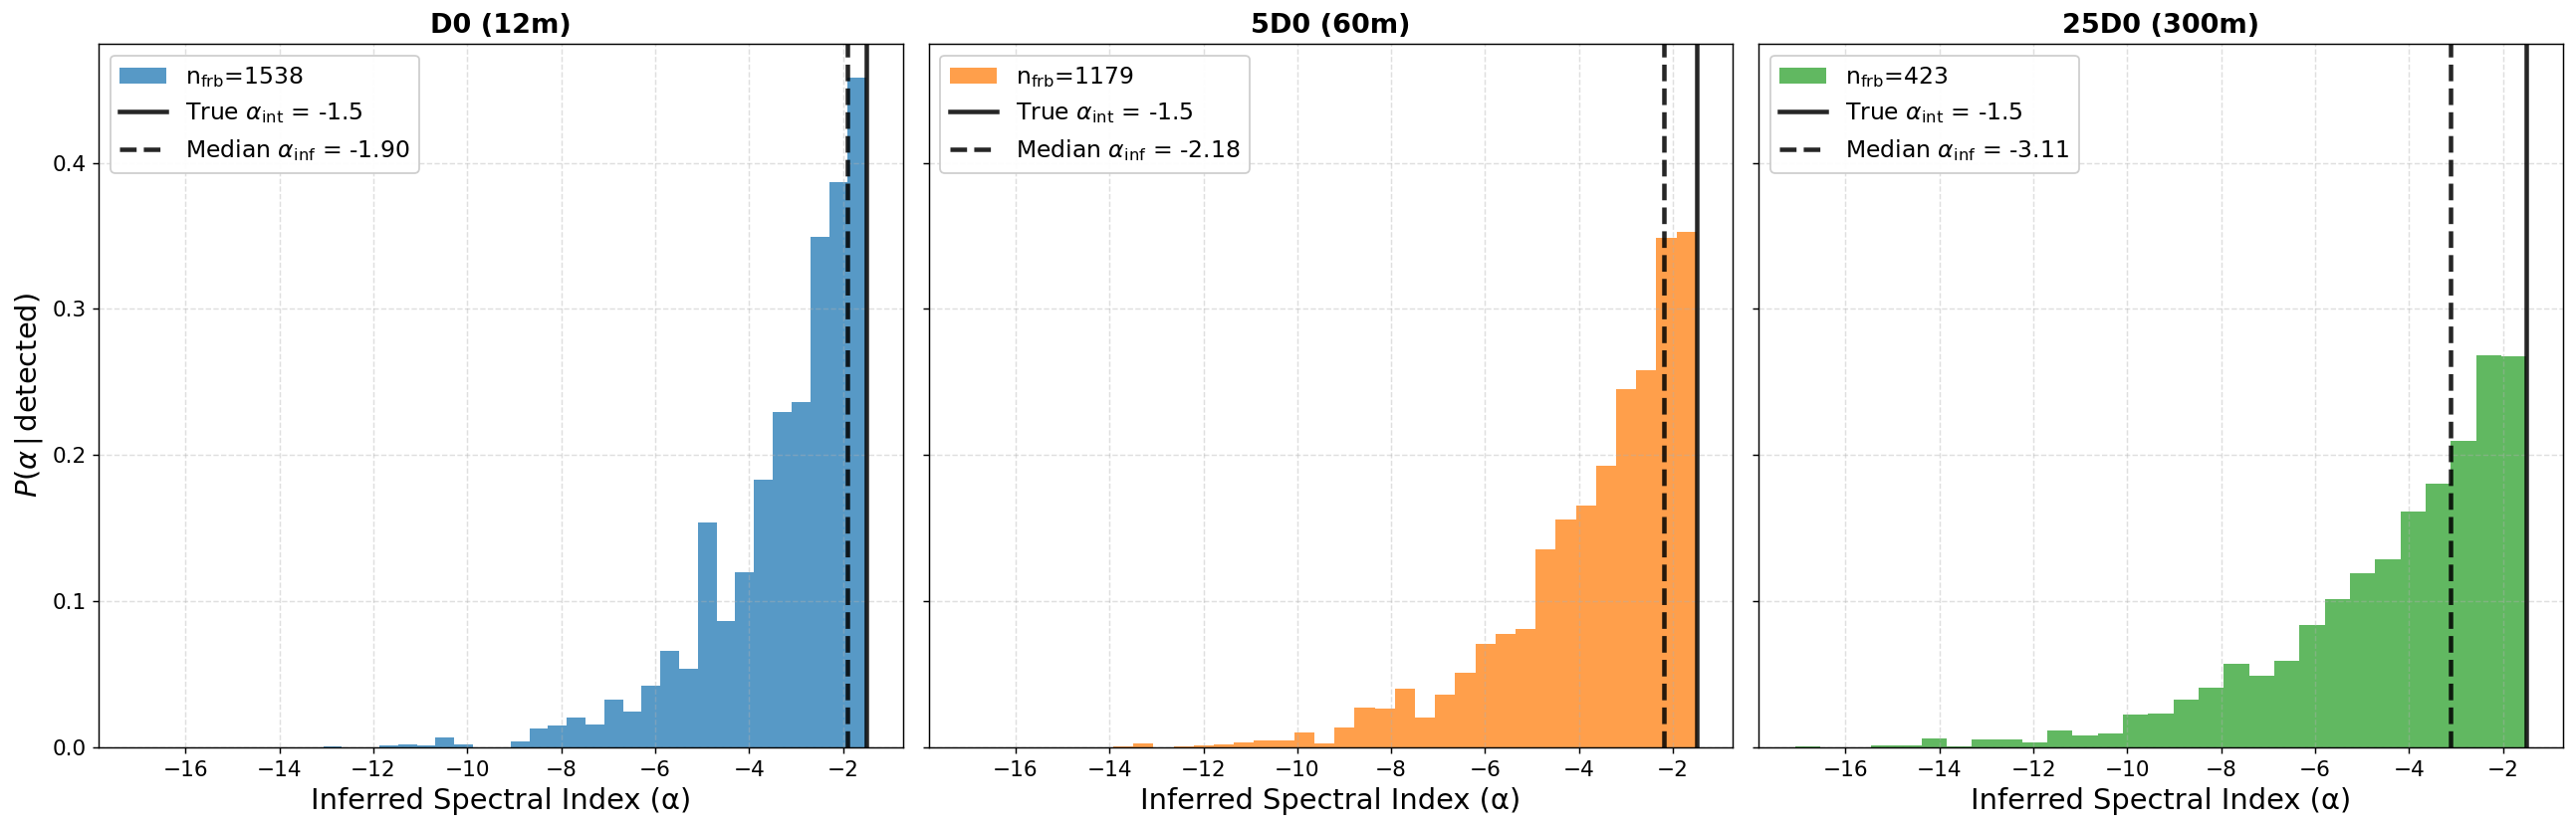

In [13]:
# ============================================================================
# PLOT: INFERRED ALPHA DISTRIBUTION, ONE PANEL PER TELESCOPE (POPULATION-WEIGHTED)
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5), dpi=130, sharex=True, sharey=True)

for idx, tel_key in enumerate(['d0', '5d0', '25d0']):
    ax = axes[idx]
    if tel_key in all_results and len(all_results[tel_key]) > 0:
        results = all_results[tel_key]

        alphas_list, weights_list = [], []
        for r in results:
            alpha_arr = r['alpha_inferred']
            valid_mask = ~np.isnan(alpha_arr)
            alpha_valid = alpha_arr[valid_mask]
            n_valid = len(alpha_valid)
            if n_valid == 0:
                continue
            per_point_weight = r['n_total_population'] / n_valid
            alphas_list.extend(alpha_valid)
            weights_list.extend([per_point_weight] * n_valid)

        alphas_arr = np.array(alphas_list)
        weights_arr = np.array(weights_list)

        bins = np.linspace(alphas_arr.min(), alphas_arr.max(), 30)
        ax.hist(alphas_arr, bins=bins, weights=weights_arr, density=True, alpha=0.75,
                color=colors_tel[tel_key], linewidth=1.2,
                label=f'n$_{{\\mathrm{{frb}}}}$={int(weights_arr.sum())}')

        ax.axvline(alpha_intrinsic, color='black', linestyle='-', linewidth=2.5,
                   label=f'True $\\alpha_{{\\rm int}}$ = {alpha_intrinsic}', alpha=0.85)
        ax.axvline(np.median(alphas_arr), color='black', linestyle='--', linewidth=2.5,
                   label=f'Median $\\alpha_{{\\rm inf}}$ = {np.median(alphas_arr):.2f}', alpha=0.85)
        ax.set_xlabel('Inferred Spectral Index (α)', fontsize=16)
        if idx == 0:
            ax.set_ylabel(r'$P(\alpha\,|\,\mathrm{detected})$', fontsize=16)
        ax.set_title(labels_tel[tel_key], fontsize=15, fontweight='bold')
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
        ax.legend(fontsize=13, loc='upper left', framealpha=0.95)

# plt.suptitle('Inferred Spectral Index Distribution, Population-Weighted', fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


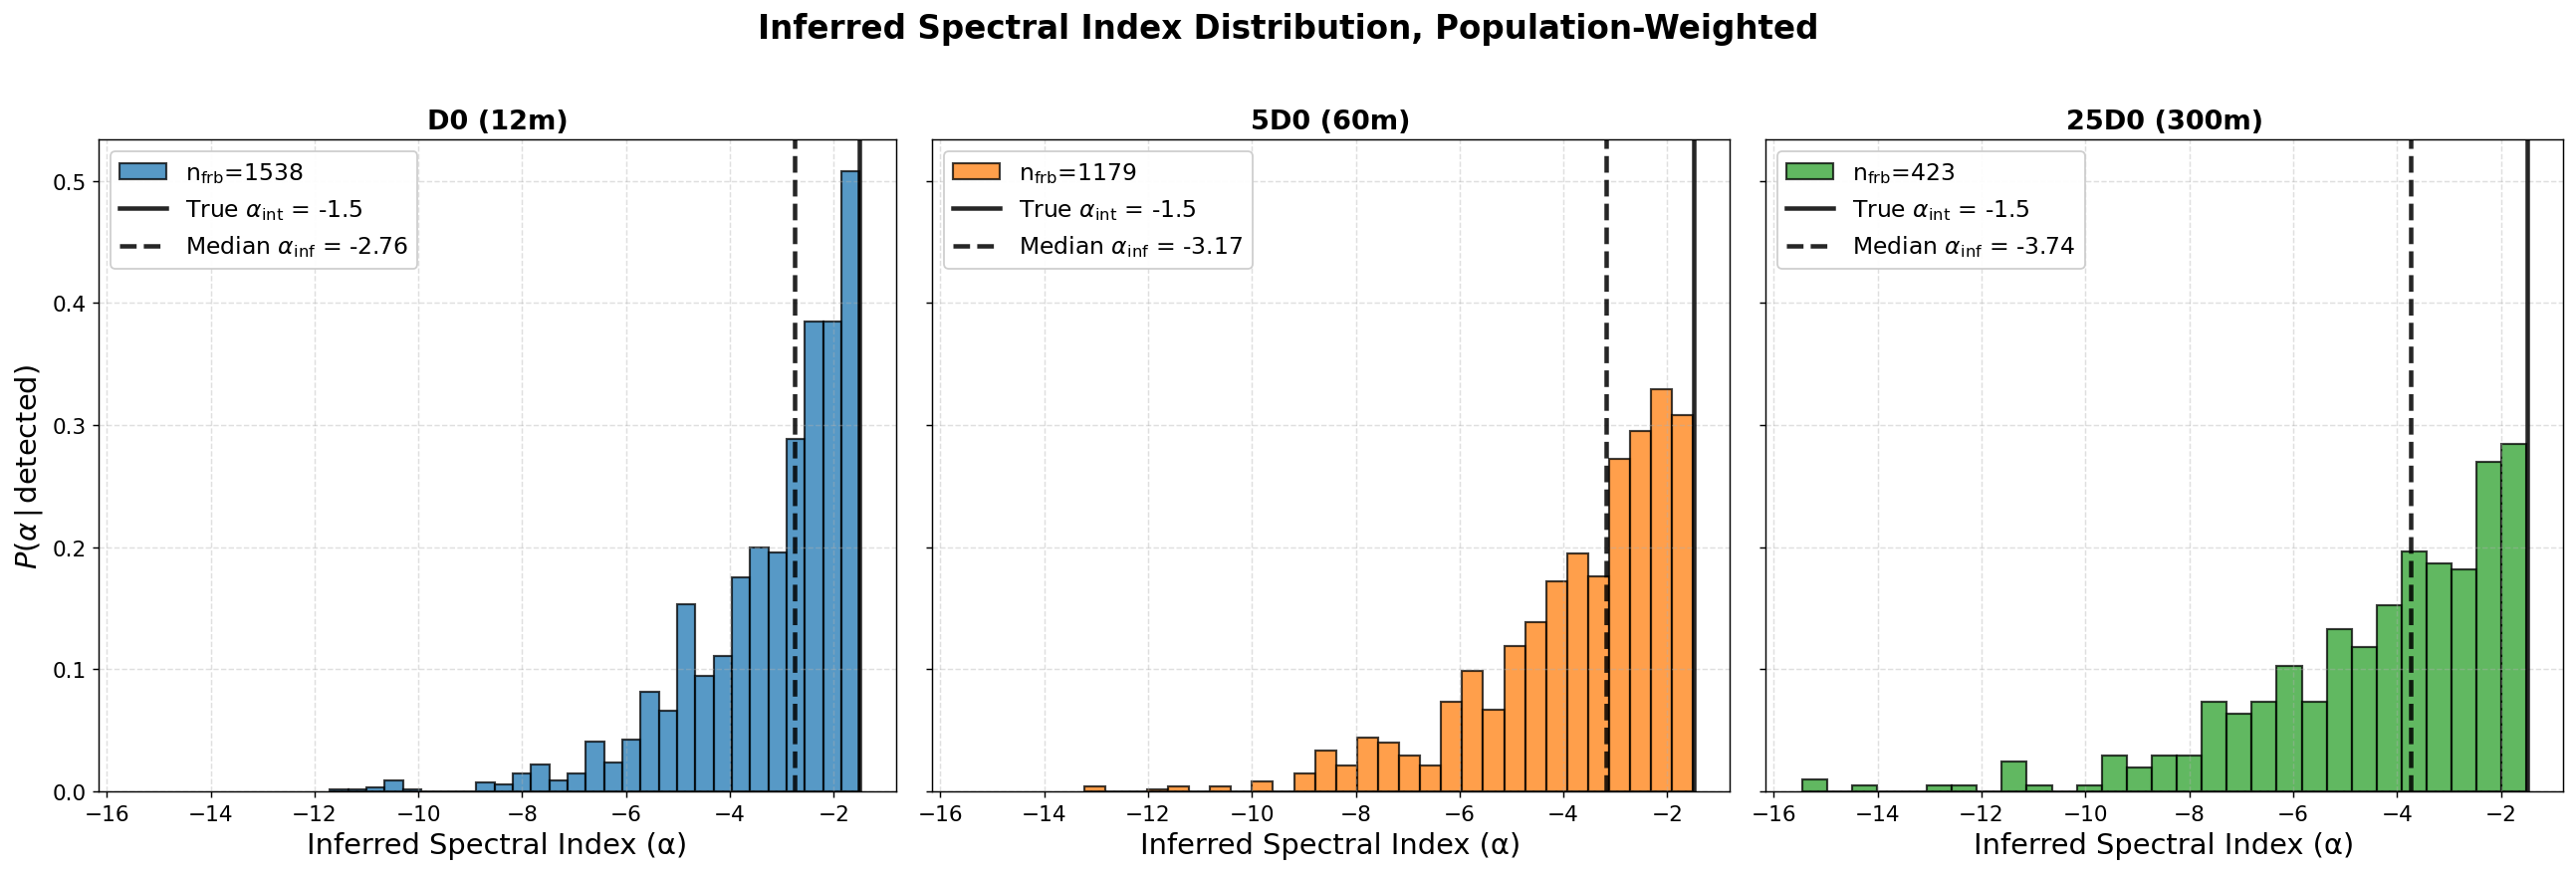

In [14]:
# ============================================================================
# PLOT: INFERRED ALPHA DISTRIBUTION, ONE PANEL PER TELESCOPE (POPULATION-WEIGHTED)
# Histogram now built from exactly n_frb resampled points, not the full weighted raw sample
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5), dpi=130, sharex=True, sharey=True)

for idx, tel_key in enumerate(['d0', '5d0', '25d0']):
    ax = axes[idx]
    if tel_key in all_results and len(all_results[tel_key]) > 0:
        results = all_results[tel_key]

        alphas_list, weights_list = [], []
        for r in results:
            alpha_arr = r['alpha_inferred']
            valid_mask = ~np.isnan(alpha_arr)
            alpha_valid = alpha_arr[valid_mask]
            n_valid = len(alpha_valid)
            if n_valid == 0:
                continue
            per_point_weight = r['n_total_population'] / n_valid
            alphas_list.extend(alpha_valid)
            weights_list.extend([per_point_weight] * n_valid)

        alphas_arr = np.array(alphas_list)
        weights_arr = np.array(weights_list)

        n_frb = int(weights_arr.sum())

        # --- Weighted resampling: draw exactly n_frb points, prob. proportional to weight ---
        probs = weights_arr / weights_arr.sum()
        sample_idx = np.random.choice(len(alphas_arr), size=n_frb, replace=True, p=probs)
        alphas_sampled = alphas_arr[sample_idx]

        bins = np.linspace(alphas_sampled.min(), alphas_sampled.max(), 30)
        ax.hist(alphas_sampled, bins=bins, density=True, alpha=0.75,
                color=colors_tel[tel_key], edgecolor='black', linewidth=1.2,
                label=f'n$_{{\\mathrm{{frb}}}}$={n_frb}')

        ax.axvline(alpha_intrinsic, color='black', linestyle='-', linewidth=2.5,
                   label=f'True $\\alpha_{{\\rm int}}$ = {alpha_intrinsic}', alpha=0.85)
        ax.axvline(np.median(alphas_sampled), color='black', linestyle='--', linewidth=2.5,
                   label=f'Median $\\alpha_{{\\rm inf}}$ = {np.median(alphas_sampled):.2f}', alpha=0.85)
        ax.set_xlabel('Inferred Spectral Index (α)', fontsize=16)
        if idx == 0:
            ax.set_ylabel(r'$P(\alpha\,|\,\mathrm{detected})$', fontsize=16)
        ax.set_title(labels_tel[tel_key], fontsize=15, fontweight='bold')
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
        ax.legend(fontsize=13, loc='upper left', framealpha=0.95)

plt.suptitle('Inferred Spectral Index Distribution, Population-Weighted', fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

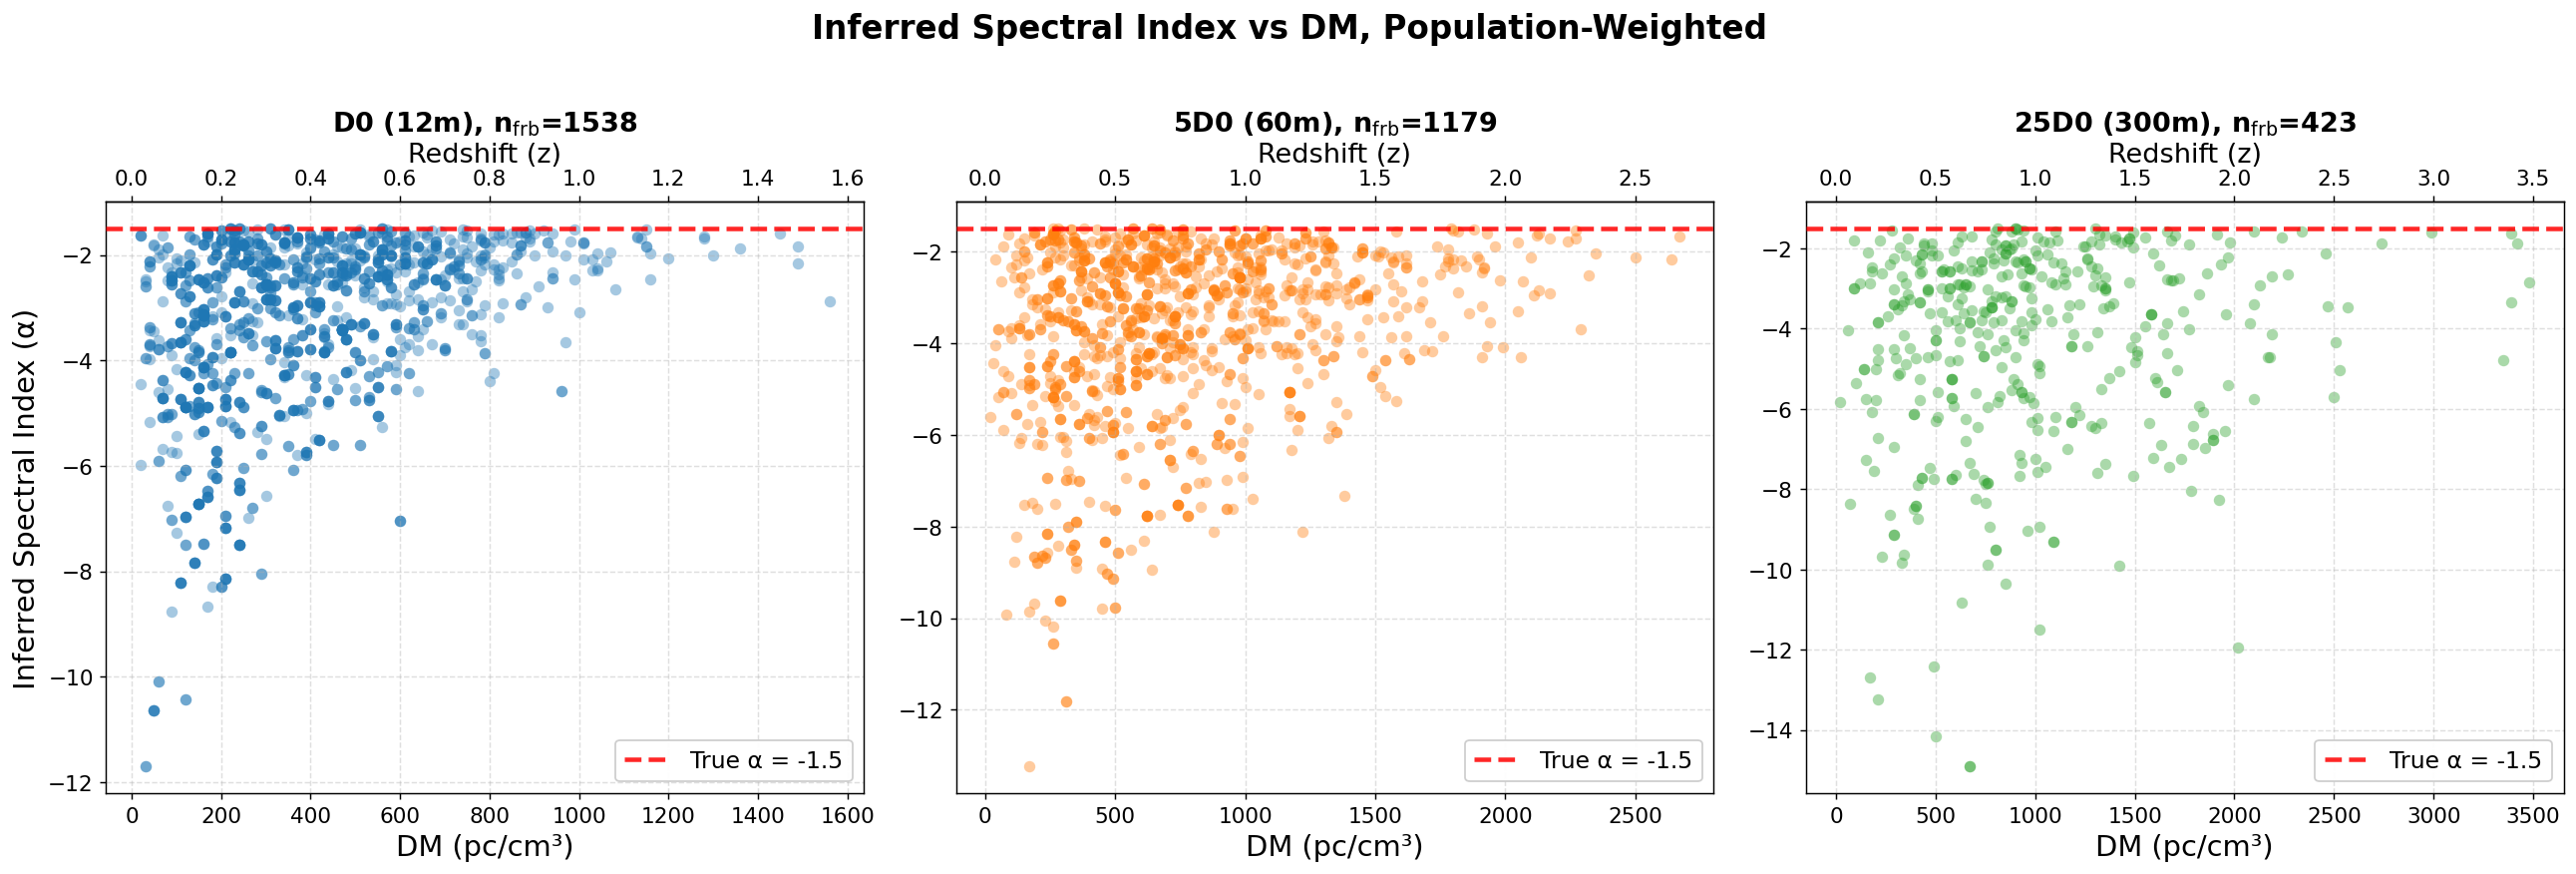

In [15]:
# ============================================================================
# PLOT: INFERRED ALPHA vs DM, ONE PANEL PER TELESCOPE (POPULATION-WEIGHTED)
# Scatter now shows exactly n_frb points (weighted resampling), not all raw MC detections
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6.5), dpi=130)

for idx, tel_key in enumerate(['d0', '5d0', '25d0']):
    ax = axes[idx]
    if tel_key in all_results and len(all_results[tel_key]) > 0:
        results = all_results[tel_key]

        dms_list, alphas_list, weights_list = [], [], []
        for r in results:
            alpha_arr = r['alpha_inferred']
            valid_mask = ~np.isnan(alpha_arr)
            alpha_valid = alpha_arr[valid_mask]
            n_valid = len(alpha_valid)
            if n_valid == 0:
                continue
            per_point_weight = r['n_total_population'] / n_valid
            dms_list.extend([r['DM']] * n_valid)
            alphas_list.extend(alpha_valid)
            weights_list.extend([per_point_weight] * n_valid)

        dms_arr = np.array(dms_list)
        alphas_arr = np.array(alphas_list)
        weights_arr = np.array(weights_list)

        n_frb = int(weights_arr.sum())

        # --- Weighted resampling: draw exactly n_frb points, prob. proportional to weight ---
        probs = weights_arr / weights_arr.sum()
        sample_idx = np.random.choice(len(dms_arr), size=n_frb, replace=True, p=probs)

        dms_sampled = dms_arr[sample_idx]
        alphas_sampled = alphas_arr[sample_idx]

        ax.scatter(dms_sampled, alphas_sampled, s=40, color=colors_tel[tel_key],
                   alpha=0.4, linewidths=0)

        ax.axhline(alpha_intrinsic, color='red', linestyle='--', linewidth=2.5,
                   label=f'True α = {alpha_intrinsic}', alpha=0.85, zorder=10)

        ax2 = ax.secondary_xaxis('top', functions=(lambda x: x/1000, lambda x: x*1000))
        ax2.set_xlabel('Redshift (z)', fontsize=15)
        ax2.tick_params(axis='x', labelsize=12)

        ax.set_xlabel('DM (pc/cm³)', fontsize=16)
        if idx == 0:
            ax.set_ylabel('Inferred Spectral Index (α)', fontsize=16)
        ax.set_title(f"{labels_tel[tel_key]}, n$_{{\\mathrm{{frb}}}}$={n_frb}",
                     fontsize=15, fontweight='bold')
        ax.tick_params(axis='both', labelsize=12)
        ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
        ax.legend(fontsize=13, loc='lower right', framealpha=0.95)

plt.suptitle('Inferred Spectral Index vs DM, Population-Weighted', fontsize=18, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [16]:
# import pickle
# out_path = "mc_all_results_cos_std.pkl"
# # out_path = "mc_all_results_cos_sch.pkl"
# # out_path = "mc_all_results_cos_sfr_sch.pkl"

# # out_path = "mc_all_results_cos_sfr_sch_smear.pkl"
# # out_path = "mc_all_results_alpha_minus_2.pkl"
# with open(out_path, "wb") as f:
#     pickle.dump(all_results, f)
# print("Saved MC pickle to", out_path)